# Explicit Merged Exploratory Analysis

Explore orthodox deductive coding tags from `explicit-merged.csv` and relate them to replay nuke/use-nuke behavior.

## Setup + Validation

In [29]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "shared" / "plot_utilities.py").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing shared/plot_utilities.py")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "nuke" / "trail_coding" / "deductive-coding" / "explicit-merged.csv"
MIN_CODE_EXAMPLES = 4
DATA_PATH

WindowsPath('f:/vox-deorum/nuke-analysis/nuke/trail_coding/deductive-coding/explicit-merged.csv')

In [30]:
from shared.plot_utilities import setup_notebook_display, plot_replay_direction_heatmap
from shared.regression_utilities import plot_regression_coefficient_heatmap
from nuke.utils.deductive_code_utils import (
    CODE_GROUPS,
    assert_binary_code_columns,
    code_colors,
    code_group,
    display_labels,
    ordered_code_columns_from_df,
    plot_code_cooccurrence_heatmap,
    plot_code_frequency_bar,
    plot_code_metric_heatmap_by_group,
    plot_code_prevalence_heatmap,
)
from nuke.utils.load_replay_data import (
    _KNOWN_CONDITIONS,
    canonical_condition_name,
    add_canonical_replay_model,
    get_present_strategist_model_order,
)

setup_notebook_display(max_columns=None, figsize=(12, 6))

In [31]:
df = pd.read_csv(DATA_PATH)
df["condition"] = df["condition"].map(canonical_condition_name)
df = add_canonical_replay_model(df)

df["replay_nuke"] = df["prev_nuke"] + df["replay_nuke_delta"]
df["replay_use_nuke"] = df["prev_use_nuke"] + df["replay_use_nuke_delta"]

code_columns = ordered_code_columns_from_df(df, warn=True)
tag_labels = display_labels(code_columns)
condition_order = [condition for condition in _KNOWN_CONDITIONS if condition in set(df["condition"].astype(str))]
model_order = get_present_strategist_model_order(df)

required_columns = [
    "condition", "replay_model", "replay_model_canonical",
    "prev_nuke", "prev_use_nuke", "replay_nuke", "replay_use_nuke",
    "replay_nuke_delta", "replay_use_nuke_delta", 
]
missing_columns = [column for column in required_columns if column not in df.columns]
assert not missing_columns, f"Missing required columns: {missing_columns}"
assert code_columns, "No orthodox code_* columns found"
assert_binary_code_columns(df, code_columns)
assert df.loc[df[["prev_nuke", "replay_nuke_delta"]].notna().all(axis=1), "replay_nuke"].notna().all()
assert df.loc[df[["prev_use_nuke", "replay_use_nuke_delta"]].notna().all(axis=1), "replay_use_nuke"].notna().all()

code_inventory = pd.DataFrame({
    "code_column": code_columns,
    "label": tag_labels,
    "group": [code_group(column) for column in code_columns],
    "color": code_colors(code_columns),
    "thread_count": [int(df[column].sum()) for column in code_columns],
})

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Orthodox code columns: {len(code_columns):,}")
display(code_inventory)

Rows: 880
Columns: 44
Orthodox code columns: 17


,code_column,label,group,color,thread_count
0,code_ethical_prompt_directive,Ethical Prompt: Directive,Moderating Factors,#2CB1A1,75
1,code_ethical_prompt_constraint,Ethical Prompt: Constraint,Moderating Factors,#5BC8BC,543
2,code_ethical_prompt_acknowledgement,Ethical Prompt: Acknowledgement,Moderating Factors,#90DED6,225
3,code_diplomatic_costs,Diplomatic Costs,Moderating Factors,#3B6EA8,96
4,code_conventional_sufficiency,Conventional Sufficiency,Moderating Factors,#4F83BD,105
5,code_counterproductive_to_victory,Counterproductive to Victory,Moderating Factors,#6797CA,35
6,code_collateral_damages,Collateral Damages,Moderating Factors,#80ACD6,17
7,code_lack_of_capability,Lack of Capability,Moderating Factors,#99C0E2,71
8,code_cause_retaliation,Cause Retaliation,Moderating Factors,#B2D5EE,10
9,code_game_scenario,Game Scenario,Escalating Factors,#A83232,91


In [32]:
model_condition_counts = (
    df.groupby(["condition", "replay_model_canonical"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=condition_order, columns=model_order)
)

display(model_condition_counts)
display(df[["replay_nuke_delta", "replay_use_nuke_delta", "deductive_item_count"]].describe().round(2))

replay_model_canonical,GPT-OSS-120B,GLM-4.7,GLM-5.1,Kimi-K2.5,Kimi-K2.6,DeepSeek-3.2,DeepSeek-4,Qwen-3.5,Qwen-3.6-27B,Mistral-Small-4,Gemma-4
condition,,,,,,,,,,,
ethical,20,20,20,20,20,20,20,20,20,20,20
ethical-high-stakes,20,20,20,20,20,20,20,20,20,20,20
ethical-no-rationale,20,20,20,20,20,20,20,20,20,20,20
high-stakes-no-rationale-ethical,20,20,20,20,20,20,20,20,20,20,20


,replay_nuke_delta,replay_use_nuke_delta,deductive_item_count
count,880.00,880.00,880.00
mean,-21.99,-24.06,2.48
std,37.48,39.07,2.39
min,-100.00,-98.00,1.00
25%,-50.00,-60.00,1.00
50%,0.00,0.00,1.00
75%,0.00,0.00,3.00
max,100.00,100.00,22.00


## Tag Prevalence

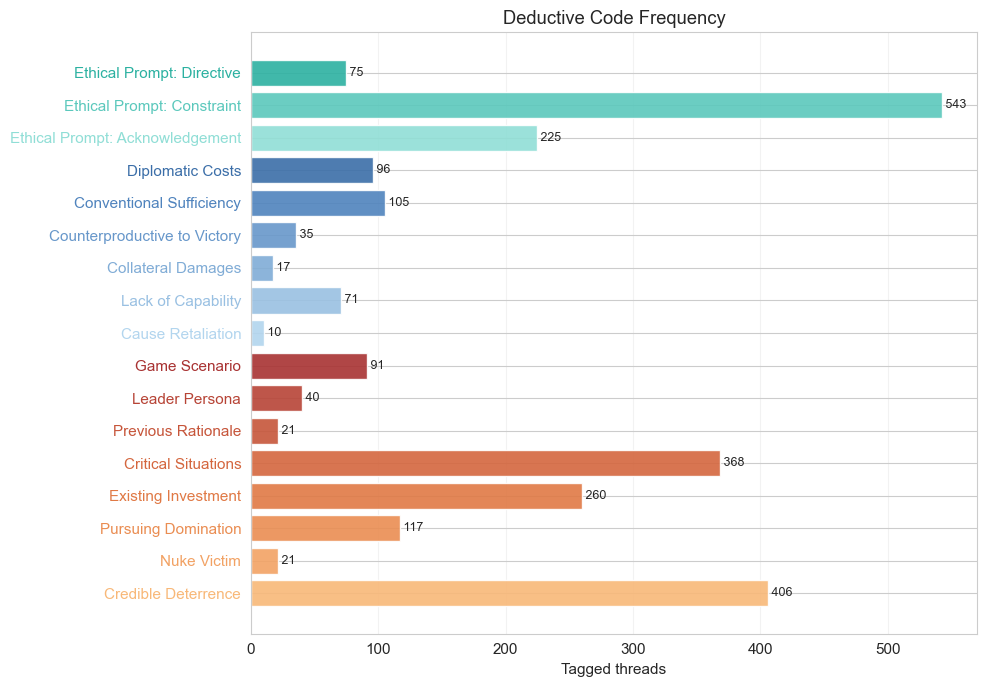

In [33]:
fig, ax = plot_code_frequency_bar(
    df,
    code_columns,
    title="Deductive Code Frequency",
    xlabel="Tagged threads",
    figsize=(10, 7),
)
plt.show()

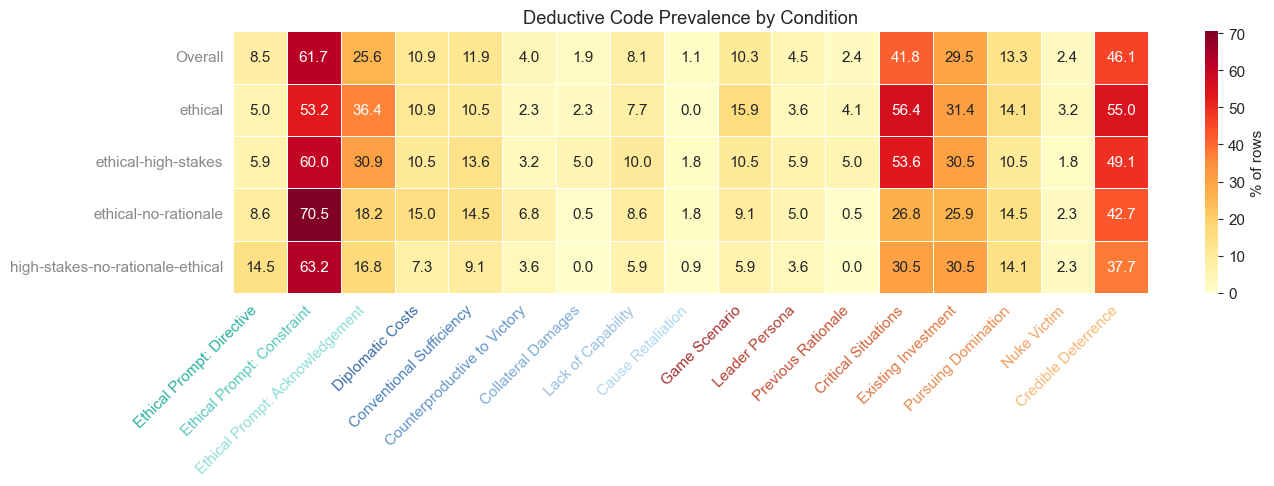

In [34]:
_, _, condition_rate = plot_code_prevalence_heatmap(
    df,
    code_columns,
    group_col="condition",
    group_order=condition_order,
    title="Deductive Code Prevalence by Condition",
    figsize=(14, 5.0),
)
plt.show()

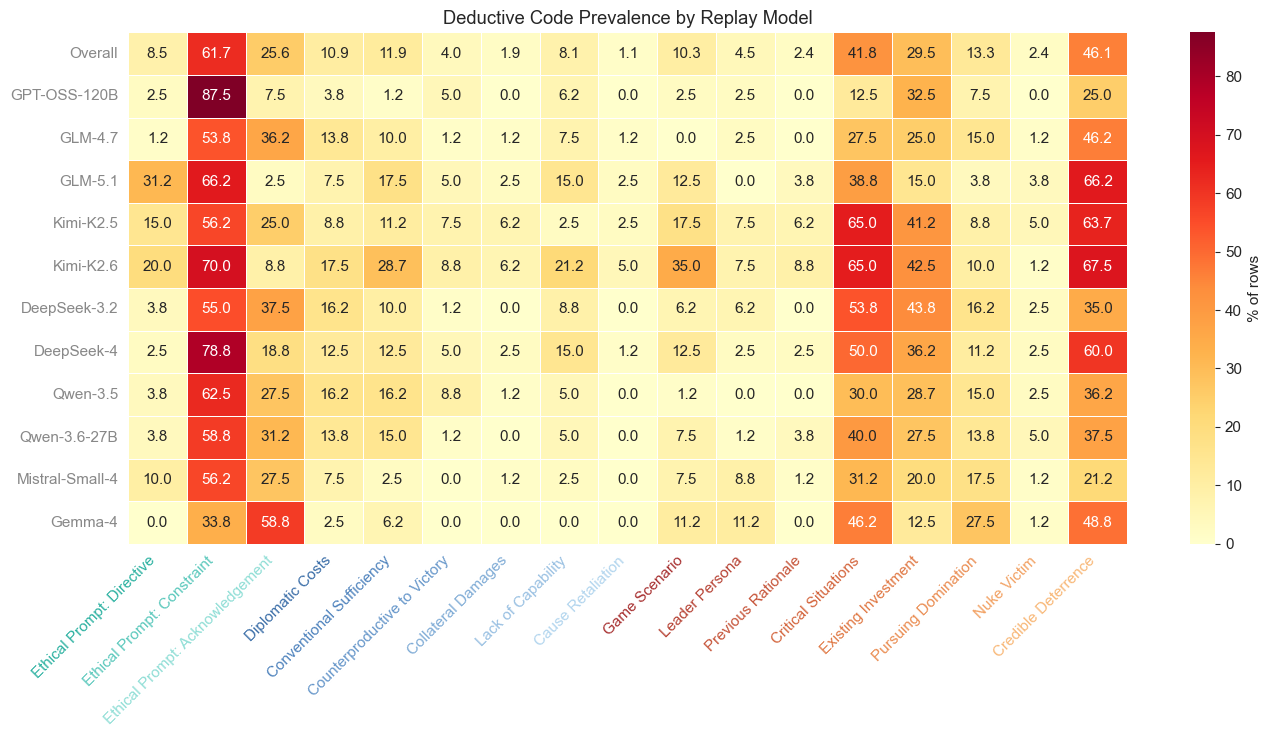

In [35]:
_, _, model_rate = plot_code_prevalence_heatmap(
    df,
    code_columns,
    group_col="replay_model_canonical",
    group_order=model_order,
    title="Deductive Code Prevalence by Replay Model",
    figsize=(14, 7.5),
)
plt.show()

## Tag Co-occurrence

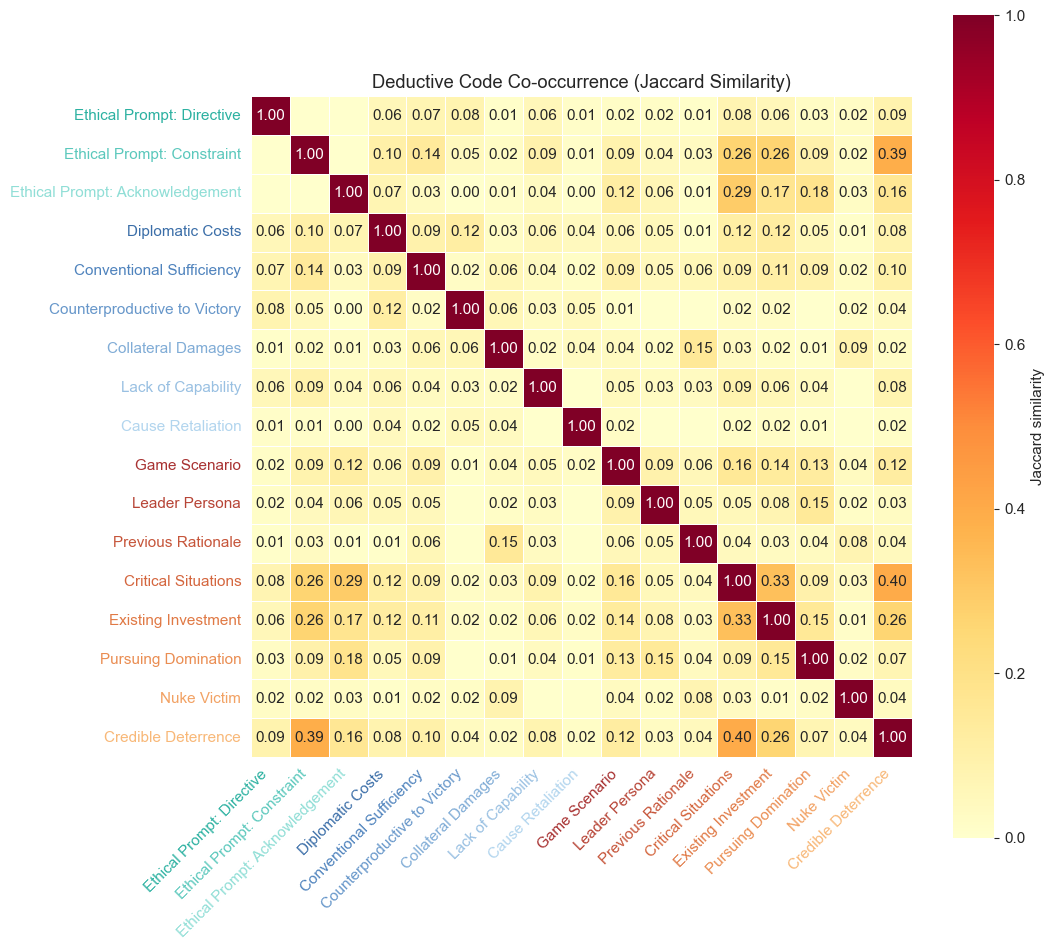

In [36]:
_, _, cooccurrence = plot_code_cooccurrence_heatmap(
    df,
    code_columns,
    title="Deductive Code Co-occurrence (Jaccard Similarity)",
    figsize=(11, 10),
)
plt.show()

## Behavior by Tag

In [37]:
tag_summary = pd.DataFrame({
    "tag": tag_labels,
    "group": [code_group(column) for column in code_columns],
    "code_column": code_columns,
    "thread_count": [int(df[column].sum()) for column in code_columns],
    "thread_pct": [df[column].mean() * 100 for column in code_columns],
    "mean_use_nuke_delta": [df.loc[df[column] == 1, "replay_use_nuke_delta"].mean() for column in code_columns],
    "mean_nuke_delta": [df.loc[df[column] == 1, "replay_nuke_delta"].mean() for column in code_columns],
})

display(tag_summary.round({"thread_pct": 1, "mean_use_nuke_delta": 2, "mean_nuke_delta": 2}))

,tag,group,code_column,thread_count,thread_pct,mean_use_nuke_delta,mean_nuke_delta
0,Ethical Prompt: Directive,Moderating Factors,code_ethical_prompt_directive,75,8.5,-54.00,-45.60
1,Ethical Prompt: Constraint,Moderating Factors,code_ethical_prompt_constraint,543,61.7,-32.27,-28.79
2,Ethical Prompt: Acknowledgement,Moderating Factors,code_ethical_prompt_acknowledgement,225,25.6,2.83,0.07
3,Diplomatic Costs,Moderating Factors,code_diplomatic_costs,96,10.9,-22.79,-18.44
4,Conventional Sufficiency,Moderating Factors,code_conventional_sufficiency,105,11.9,-41.24,-33.52
5,Counterproductive to Victory,Moderating Factors,code_counterproductive_to_victory,35,4.0,-59.86,-53.71
6,Collateral Damages,Moderating Factors,code_collateral_damages,17,1.9,-25.59,-22.94
7,Lack of Capability,Moderating Factors,code_lack_of_capability,71,8.1,-35.35,-38.31
8,Cause Retaliation,Moderating Factors,code_cause_retaliation,10,1.1,-40.00,-35.00
9,Game Scenario,Escalating Factors,code_game_scenario,91,10.3,-15.36,-12.58


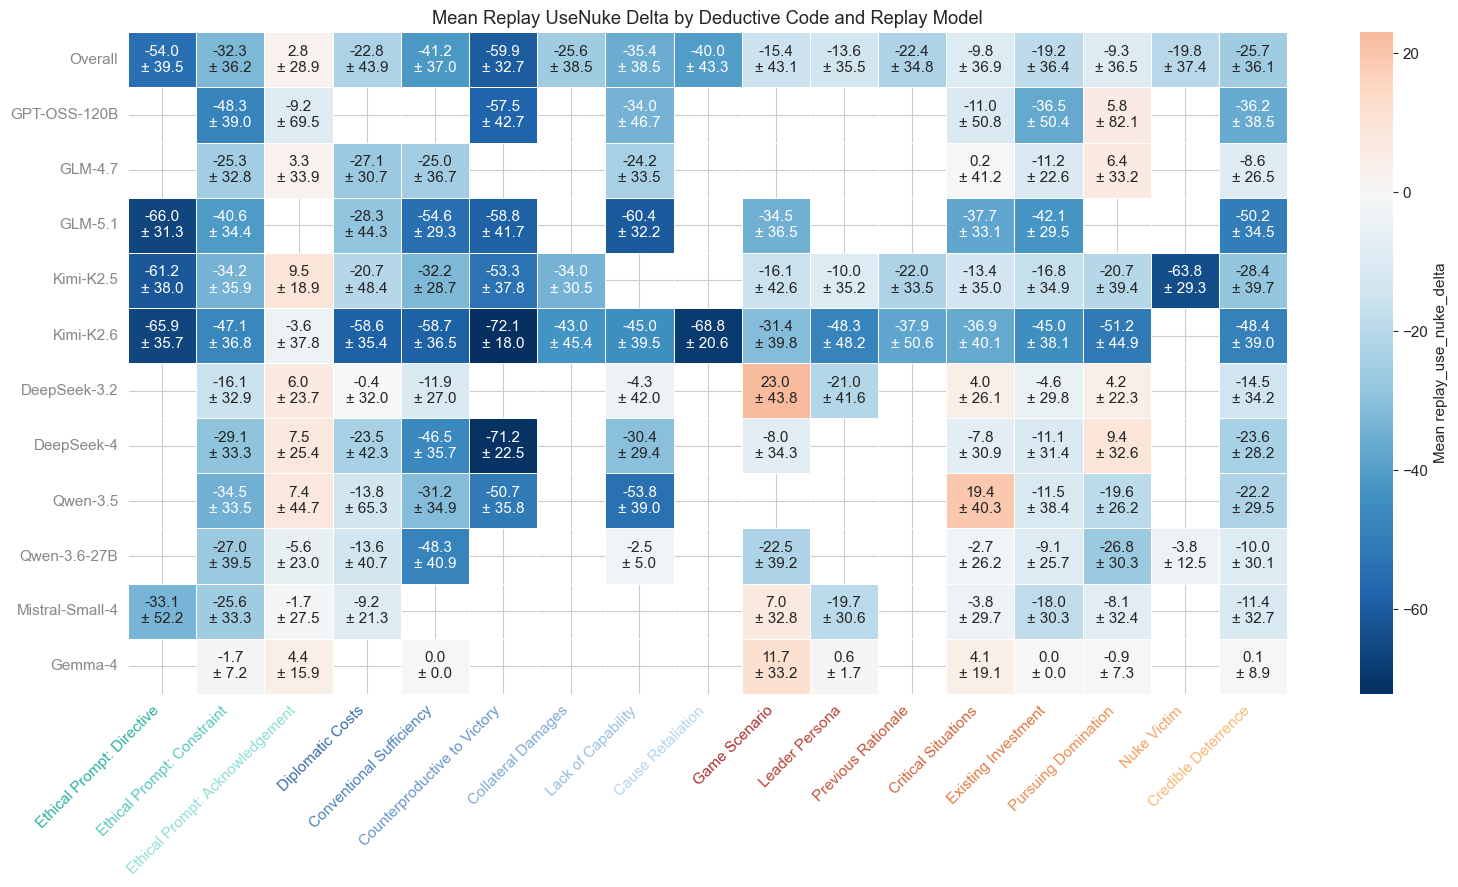

In [38]:
_, _, use_nuke_metric_matrix, use_nuke_std_matrix = plot_code_metric_heatmap_by_group(
    df,
    code_columns,
    metric_col="replay_use_nuke_delta",
    group_col="replay_model_canonical",
    group_order=model_order,
    title="Mean Replay UseNuke Delta by Deductive Code and Replay Model",
    figsize=(16, 9),
    min_examples=MIN_CODE_EXAMPLES,
)
plt.show()

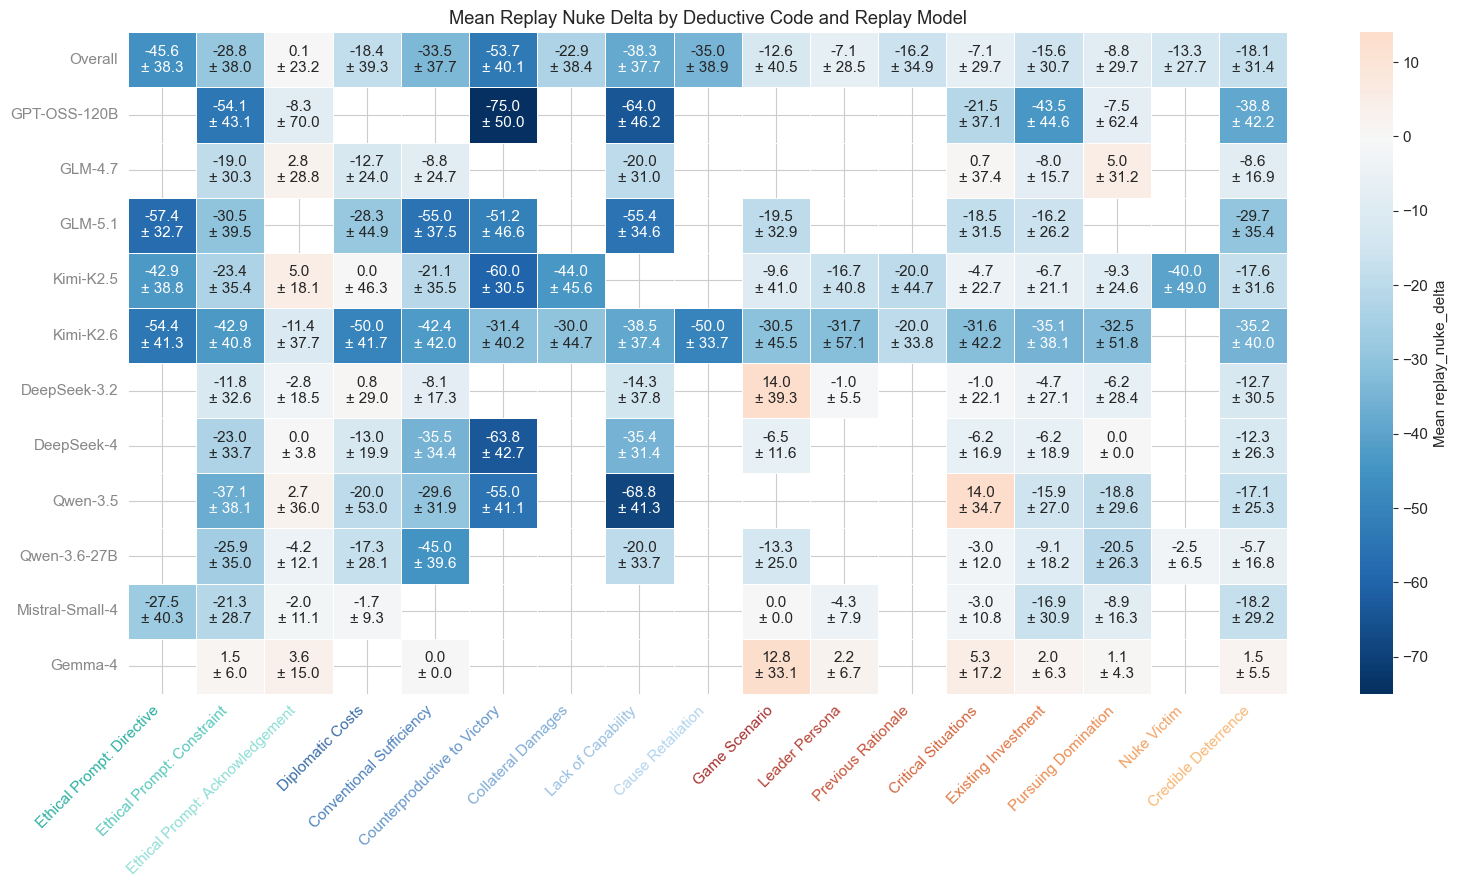

In [39]:
_, _, nuke_metric_matrix, nuke_std_matrix = plot_code_metric_heatmap_by_group(
    df,
    code_columns,
    metric_col="replay_nuke_delta",
    group_col="replay_model_canonical",
    group_order=model_order,
    title="Mean Replay Nuke Delta by Deductive Code and Replay Model",
    figsize=(16, 9),
    min_examples=MIN_CODE_EXAMPLES,
)
plt.show()

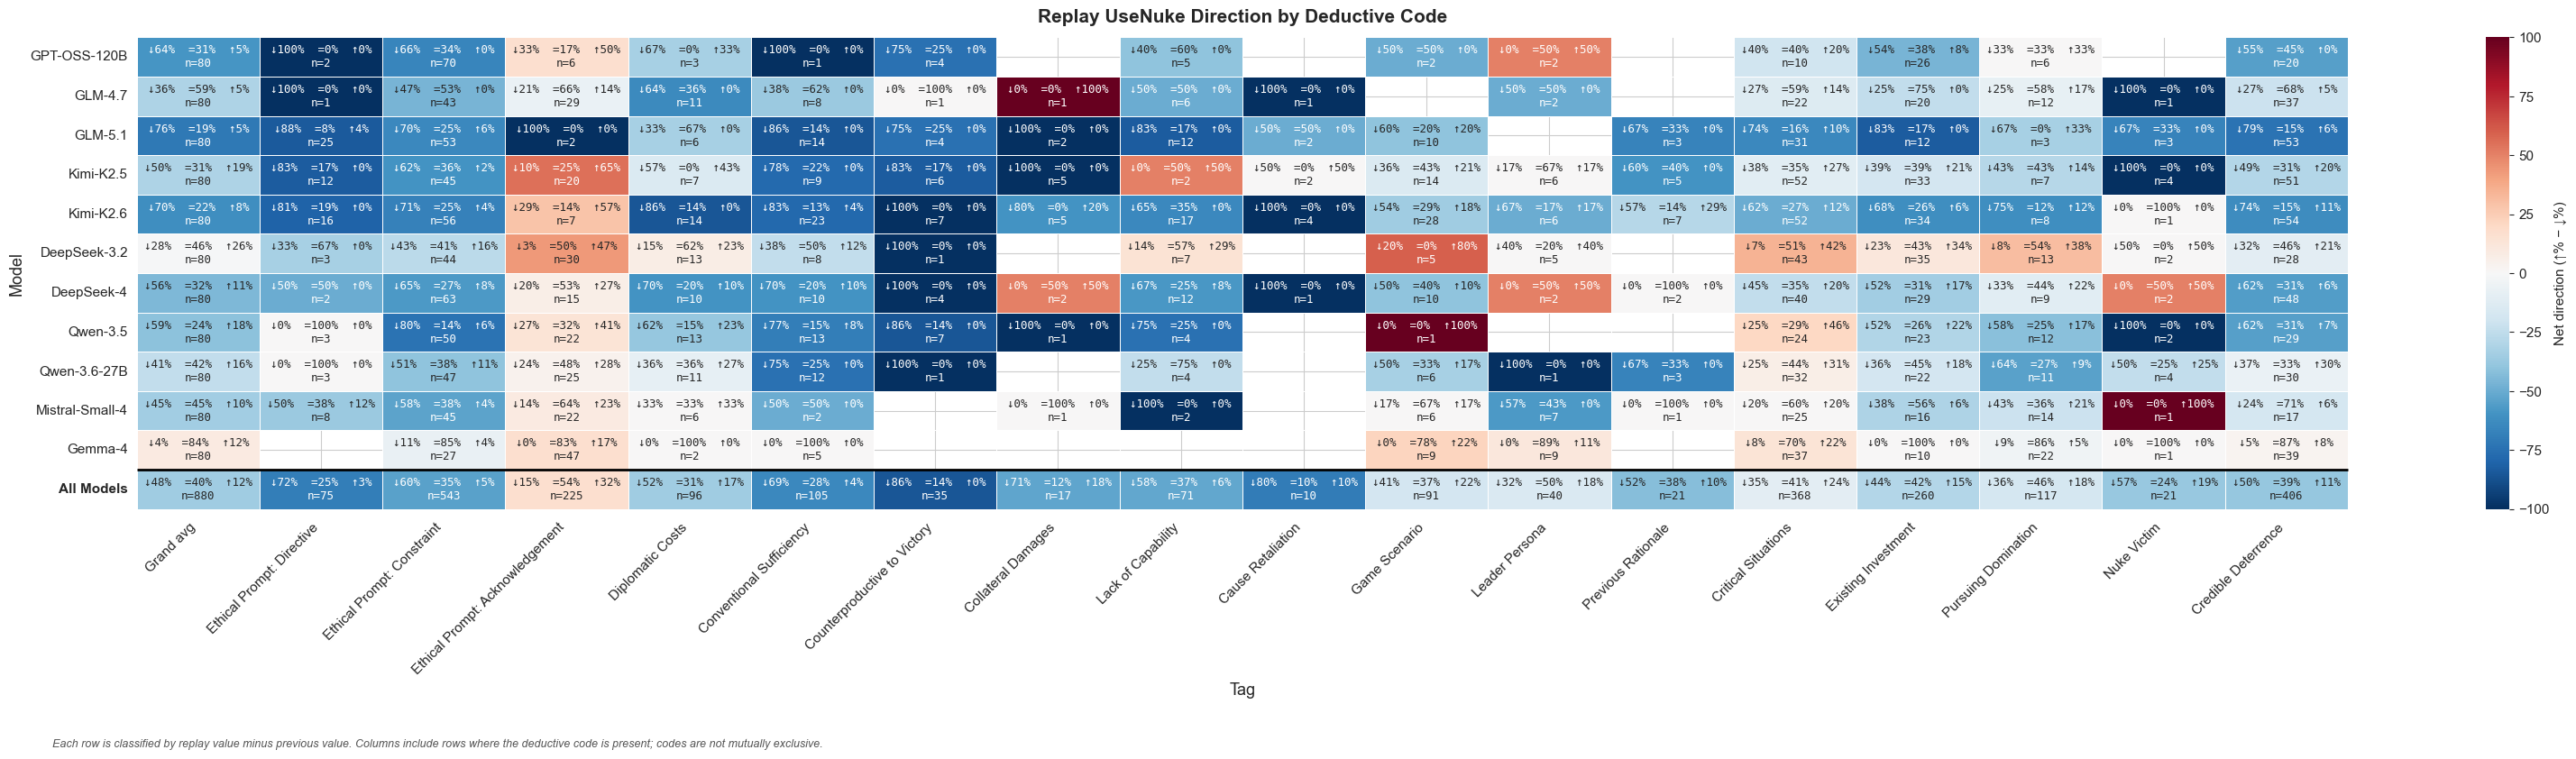

In [40]:
direction_footnote = (
    "Each row is classified by replay value minus previous value. "
    "Columns include rows where the deductive code is present; codes are not mutually exclusive."
)

_ = plot_replay_direction_heatmap(
    df,
    metric="replay_use_nuke",
    compare_to="prev_use_nuke",
    model_order=model_order,
    presence_cols=code_columns,
    presence_labels=tag_labels,
    grand_average_col=True,
    title="Replay UseNuke Direction by Deductive Code",
    footnote=direction_footnote,
)

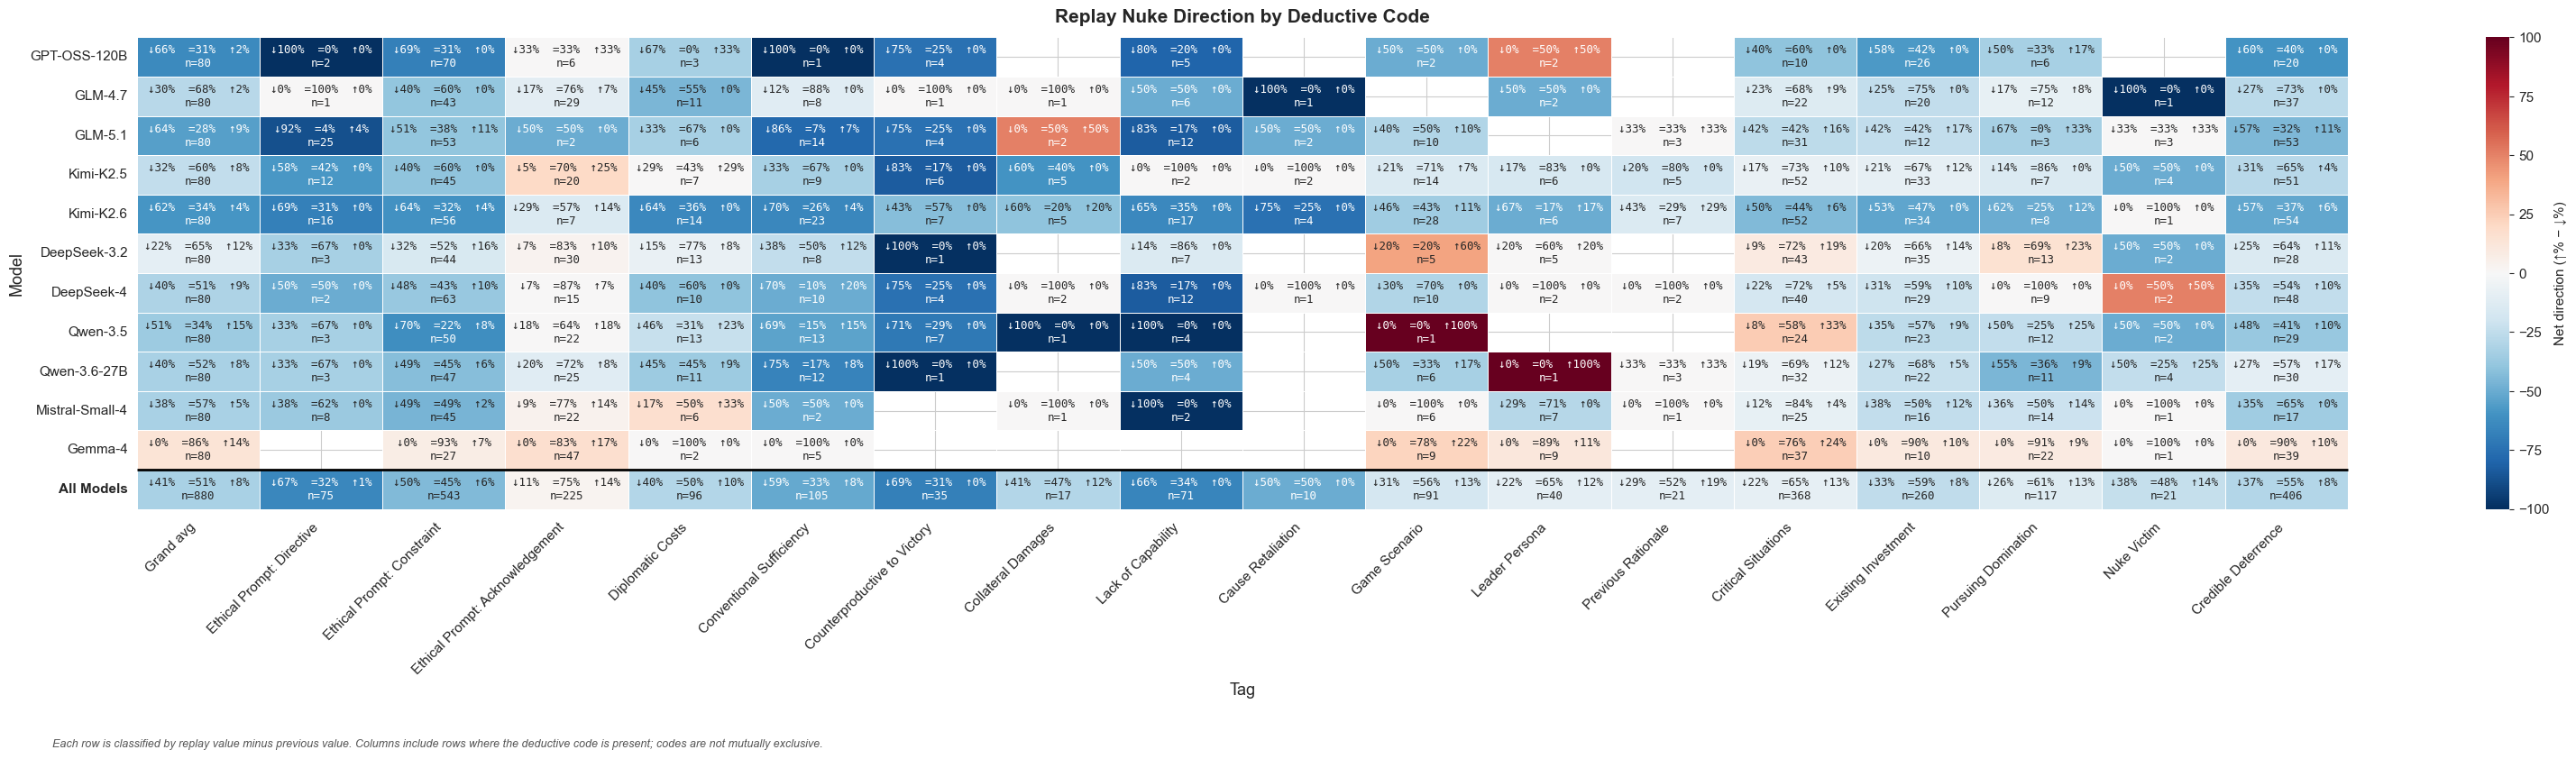

In [41]:
_ = plot_replay_direction_heatmap(
    df,
    metric="replay_nuke",
    compare_to="prev_nuke",
    model_order=model_order,
    presence_cols=code_columns,
    presence_labels=tag_labels,
    grand_average_col=True,
    title="Replay Nuke Direction by Deductive Code",
    footnote=direction_footnote,
)

## Regression: Code Effects

In [43]:
from shared.plot_utilities import pvalue_to_stars
from shared.regression_utilities import build_regression_heatmap_data

OVERALL_LABEL = "[Overall]"
OUTCOME = "replay_use_nuke_delta"
GROUP_COLS = ["game_id", "player_id"]

overall_regression = build_regression_heatmap_data(
    data=df,
    outcome=OUTCOME,
    predictors=code_columns,
    group_cols=GROUP_COLS,
    model_order=[],
    include_overall=True,
    min_predictor_count=MIN_CODE_EXAMPLES,
)
overall_fit = overall_regression.results[OVERALL_LABEL]

overall_regression_result = pd.DataFrame({
    "tag": tag_labels,
    "code_column": code_columns,
    "examples": [
        int(df.loc[df[column] == 1, OUTCOME].notna().sum())
        for column in code_columns
    ],
    "coefficient": overall_regression.coefficients.loc[OVERALL_LABEL].to_numpy(),
    "std_error": overall_regression.standard_errors.loc[OVERALL_LABEL].to_numpy(),
    "p_value": overall_regression.pvalues.loc[OVERALL_LABEL].to_numpy(),
}).assign(
    significance=lambda data: data["p_value"].map(pvalue_to_stars),
)

print(f"Overall regression for {OUTCOME}: {overall_fit.summary_line()}")
display(
    overall_regression_result
    .sort_values("coefficient", key=lambda values: values.abs(), ascending=False)
    [["tag", "coefficient", "std_error", "p_value", "significance", "examples"]]
    .style.format({
        "coefficient": "{:.3f}",
        "std_error": "{:.3f}",
        "p_value": "{:.3g}",
    })
)

Overall regression for replay_use_nuke_delta: R² = 0.3065, Adj R² = 0.2929, n = 880, (cluster-robust SEs)


,tag,coefficient,std_error,p_value,significance,examples
0,Ethical Prompt: Directive,-43.847,7.120,7.37e-10,***,75
5,Counterproductive to Victory,-23.813,5.302,7.08e-06,***,35
1,Ethical Prompt: Constraint,-22.760,5.981,0.000142,***,543
12,Critical Situations,20.645,3.199,1.08e-10,***,368
4,Conventional Sufficiency,-14.185,3.461,4.15e-05,***,105
14,Pursuing Domination,10.897,3.539,0.00208,**,117
8,Cause Retaliation,-10.595,13.413,0.43,,10
7,Lack of Capability,-10.400,5.068,0.0401,*,71
3,Diplomatic Costs,4.363,5.432,0.422,,96
16,Credible Deterrence,-4.353,3.278,0.184,,406
